In [1]:
## Log - transformation doesn't guarantee normal distribution always.
## If the original data is log-normal distribution then only log transformation can make normal distribution

## Box - Cox transformation
- Its used to reduce skewness of the data and make it more nomally distributed
- We can change the value of lambda and see which value suits best for given data

In [ ]:
## Log - transformation is a special case of box-cox transformation

## General formula for box cox

'''
x' = ((x^lambda) - 1)/lambda   if lambda !=0

x' = log(x)                    if lambda = 0 (log-transformation)
'''

## Data Distribution case-study : Tips dataset

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='Count'>

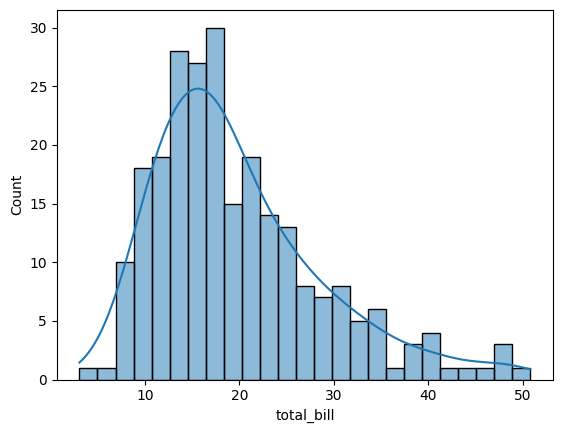

In [7]:
sns.histplot(tips['total_bill'],kde=True,bins=25)

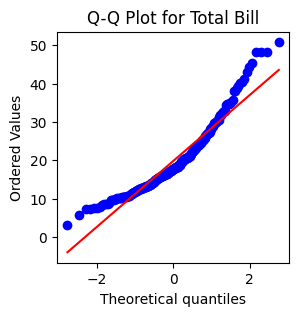

In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3, 3))
stats.probplot(tips['total_bill'], dist='norm', plot=ax)
ax.set_title('Q-Q Plot for Total Bill')
plt.show()

In [16]:
## Total bill dataset is skewed and not nearly normal
## We can transform total bill data using log-transform and box-cox transform to make it normal

In [18]:
tips['log_total_bill']=np.log(tips['total_bill'])

<Axes: xlabel='log_total_bill', ylabel='Count'>

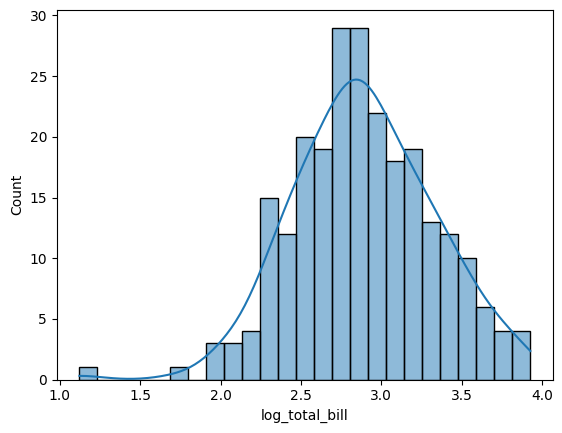

In [20]:
sns.histplot(tips['log_total_bill'],kde=True,bins=25)

## skewness in the data has been reduced after log-transform

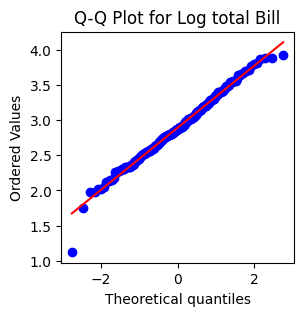

In [21]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3, 3))
stats.probplot(tips['log_total_bill'], dist='norm', plot=ax)
ax.set_title('Q-Q Plot for Log total Bill')
plt.show()

## qq plot for log total bill follows straight line better than qq plot of total bill
## which shows that skewness has been reduced and data has become more symmetrical/normal

In [23]:
## box cox transformation of total bill data

box_cox_total_bill,lambda_total_bill = stats.boxcox(tips['total_bill'])

In [24]:
lambda_total_bill

np.float64(0.07691914552205643)

<Axes: ylabel='Count'>

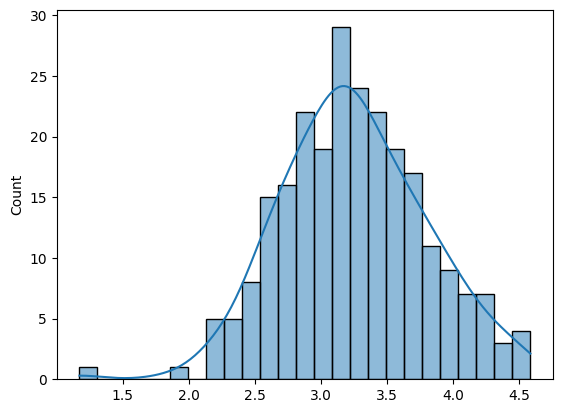

In [26]:
sns.histplot(box_cox_total_bill,kde=True,bins=25)

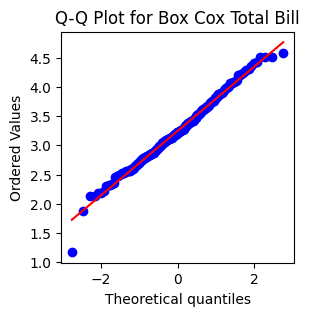

In [27]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3, 3))
stats.probplot(box_cox_total_bill, dist='norm', plot=ax)
ax.set_title('Q-Q Plot for Box Cox Total Bill')
plt.show()

## qq plot after box-cox transform is following a straight line
## optimal value of lambda found is 0.077

<Axes: xlabel='tip', ylabel='Count'>

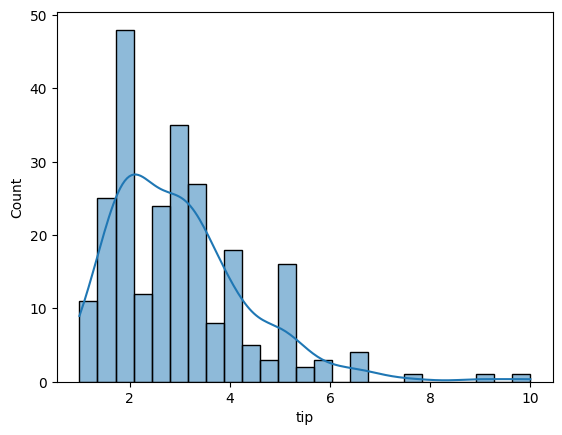

In [15]:
sns.histplot(tips['tip'],kde=True,bins=25)

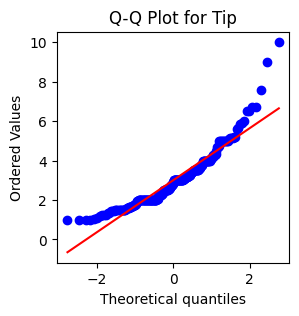

In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3, 3))
stats.probplot(tips['tip'], dist='norm', plot=ax)
ax.set_title('Q-Q Plot for Tip')
plt.show()

In [29]:
tips['log_tip']=np.log(tips['tip'])
tips

,total_bill,tip,sex,smoker,day,time,size,log_total_bill,log_tip
0,16.99,1.01,Female,No,Sun,Dinner,2,2.832625,0.009950
1,10.34,1.66,Male,No,Sun,Dinner,3,2.336020,0.506818
2,21.01,3.50,Male,No,Sun,Dinner,3,3.044999,1.252763
3,23.68,3.31,Male,No,Sun,Dinner,2,3.164631,1.196948
4,24.59,3.61,Female,No,Sun,Dinner,4,3.202340,1.283708
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,3.368330,1.778336
240,27.18,2.00,Female,Yes,Sat,Dinner,2,3.302481,0.693147
241,22.67,2.00,Male,Yes,Sat,Dinner,2,3.121042,0.693147
242,17.82,1.75,Male,No,Sat,Dinner,2,2.880321,0.559616


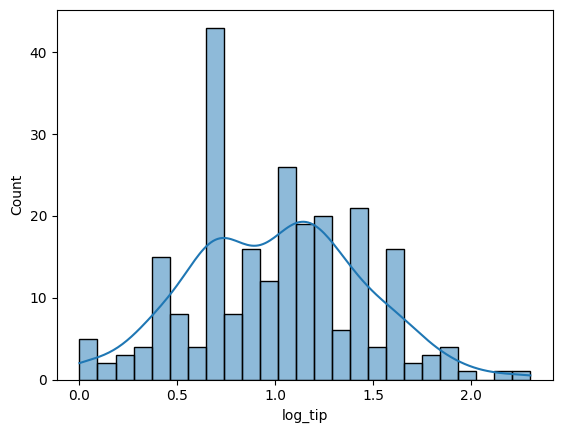

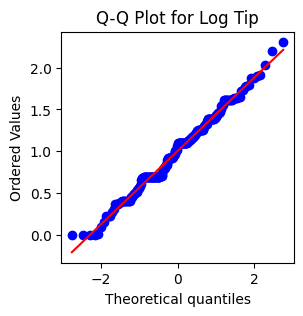

In [30]:
sns.histplot(tips['log_tip'],kde=True,bins=25)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3, 3))
stats.probplot(tips['log_tip'], dist='norm', plot=ax)
ax.set_title('Q-Q Plot for Log Tip')
plt.show()

In [31]:
## box cox transformation of total bill data

box_cox_tip,lambda_tip = stats.boxcox(tips['tip'])
print(lambda_tip)

-0.06325975857438766


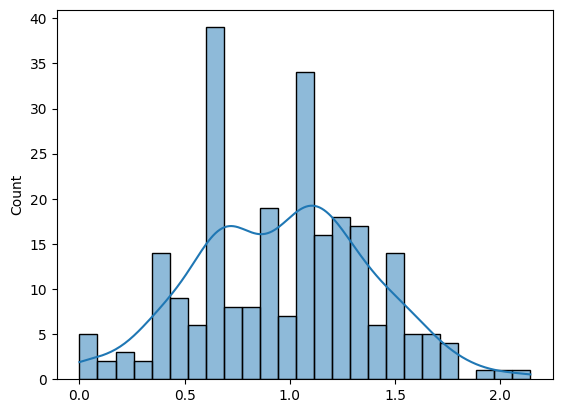

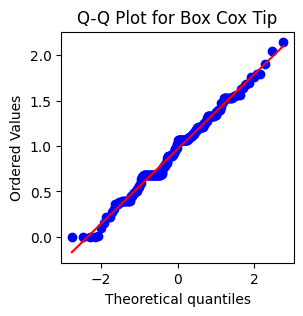

In [32]:
sns.histplot(box_cox_tip,kde=True,bins=25)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3, 3))
stats.probplot(box_cox_tip, dist='norm', plot=ax)
ax.set_title('Q-Q Plot for Box Cox Tip')
plt.show()

## Feature Scaling
- Its a technique to adjust the scale of variables(columns/features) in a dataset so they follow a common scale.
- This ensures that no feature dominates others due to difference in range or magnitude.

- Popular techniques for feature scaling are 1) Z-score scaling (Standardization)
2)Min-Max scaling

In [33]:
tips

,total_bill,tip,sex,smoker,day,time,size,log_total_bill,log_tip
0,16.99,1.01,Female,No,Sun,Dinner,2,2.832625,0.009950
1,10.34,1.66,Male,No,Sun,Dinner,3,2.336020,0.506818
2,21.01,3.50,Male,No,Sun,Dinner,3,3.044999,1.252763
3,23.68,3.31,Male,No,Sun,Dinner,2,3.164631,1.196948
4,24.59,3.61,Female,No,Sun,Dinner,4,3.202340,1.283708
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,3.368330,1.778336
240,27.18,2.00,Female,Yes,Sat,Dinner,2,3.302481,0.693147
241,22.67,2.00,Male,Yes,Sat,Dinner,2,3.121042,0.693147
242,17.82,1.75,Male,No,Sat,Dinner,2,2.880321,0.559616
